# 09-Graph Machine Learning at Scale (DGL — Deep Graph Library)

Lesson 8's `ManualGCN` computed $H^{(l+1)} = \sigma(\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}H^{(l)}W^{(l)})$ as one dense matrix multiplication touching the *entire* adjacency matrix on every forward pass — fine for 20 nodes, catastrophic for a graph with a billion edges, where $\hat{A}$ alone would not fit in any single machine's memory. Full-batch GNN training also means every gradient step waits for the whole graph, so there is no way to trade a little statistical noise for much faster iteration the way ordinary mini-batch SGD does for i.i.d. data.

**DGL (Deep Graph Library)** solves this with **neighbor sampling**: instead of aggregating a node's FULL neighborhood, a mini-batch samples a bounded, fixed-size subset of neighbors per node per layer, building a small "computation block" that trains in constant memory regardless of how large the full graph is or how skewed its degree distribution gets. This is the mechanism that makes GNN training on graphs with hundreds of millions of nodes tractable on ordinary GPUs, and it is DGL's signature capability alongside multi-machine distributed partitioning. We implement neighbor sampling and mini-batch message passing ourselves in raw `torch`, then attempt the equivalent production pipeline via DGL's `dgl.dataloading` API.


## 1. The Mathematics of Sampled, Distributed Graph Learning

### The Neighbor Explosion Problem

A full-batch $L$-layer GNN forward pass touches every node's $L$-hop neighborhood. For a node with average degree $d$, an $L$-hop neighborhood has up to $O(d^L)$ nodes — for a social graph with $d \approx 100$ and $L=3$, that is up to $10^6$ nodes pulled in to compute the gradient for ONE training example. This exponential blow-up is the **neighbor explosion problem**, and it is what makes full-batch training infeasible at scale.

### Neighbor Sampling (GraphSAGE-style Mini-Batching)

DGL bounds this by fixing a **fan-out** $s_l$ (max neighbors sampled) at each layer $l$. For a mini-batch of target (seed) nodes $\mathcal{B}^{(L)}$, sampling proceeds backward from the output layer to the input layer, building nested node sets:

$$\mathcal{B}^{(l-1)} = \mathcal{B}^{(l)} \cup \bigcup_{v \in \mathcal{B}^{(l)}} \text{SAMPLE}\big(N(v),\ s_l\big), \qquad l = L, L-1, \dots, 1$$

Each consecutive pair $(\mathcal{B}^{(l-1)}, \mathcal{B}^{(l)})$ forms a **block** — a bipartite graph of sampled edges between input-layer nodes and output-layer nodes — and the total per-batch computation is bounded by $O\!\left(\prod_{l=1}^{L} s_l\right)$ regardless of the full graph's degree distribution.

### Message Passing on a Block

Within one block, the update is the same message-passing form as Lesson 8, restricted to the SAMPLED neighbor set $N_s(v) \subseteq N(v)$, $|N_s(v)| \le s_l$:

$$h_v^{(l)} = \phi\left(h_v^{(l-1)},\ \frac{1}{|N_s(v)|}\sum_{u \in N_s(v)} \psi\big(h_u^{(l-1)}\big)\right)$$

This mean-aggregator form is exactly GraphSAGE's `mean` variant, and it is an unbiased (in expectation, under uniform sampling) Monte Carlo estimate of the full-neighborhood aggregate — the same bias-variance trade ordinary SGD makes by sub-sampling training examples, here applied to a node's neighborhood instead.

### Graph Partitioning for Distributed Training

At multi-machine scale, DGL first partitions $V$ into $P$ disjoint parts $\{V_1, \dots, V_P\}$ (typically via METIS) to minimize the **edge cut** while keeping partitions balanced:

$$\min_{V_1,\dots,V_P} \sum_{i<j} \big|E(V_i, V_j)\big| \quad \text{subject to} \quad \max_i |V_i| \le (1+\epsilon)\frac{|V|}{P}$$

Each machine trains on its own partition and fetches only the small "halo" of remote neighbor features actually needed for cross-partition sampled edges via a distributed key-value store — total network traffic scales with the edge cut, which is exactly why minimizing it, not just balancing node counts, is the objective.


## 2. Imperative Execution: Neighbor Sampling and Mini-Batch Message Passing

We build a larger synthetic graph (400 nodes, 4 communities) that would be wasteful to train full-batch, implement fan-out neighbor sampling and mini-batch mean-aggregation message passing ourselves in raw `torch`, simulate a METIS-style partitioning for a distributed setting, then attempt the equivalent production pipeline via DGL's `dataloading.NeighborSampler`.

In [1]:
# Required installations: pip install dgl torch
import numpy as np
import torch
import torch.nn as nn
import networkx as nx

print("--- 🚀 Initializing Graph ML at Scale Sandbox (DGL) ---")

torch.manual_seed(42)
rng = np.random.default_rng(42)

# 1. 📝 Construct a larger 4-community graph -- large enough that full-batch training is wasteful
n_per_comm, n_comms = 100, 4
n = n_per_comm * n_comms
G = nx.Graph()
G.add_nodes_from(range(n))
for c in range(n_comms):
    members = list(range(c * n_per_comm, (c + 1) * n_per_comm))
    for i in members:
        # each node connects to ~6 random same-community peers (sparse, not all-pairs -- realistic degree)
        peers = rng.choice(members, size=6, replace=False)
        for p in peers:
            if p != i:
                G.add_edge(i, int(p))
for _ in range(30):  # sparse cross-community bridges
    G.add_edge(int(rng.integers(0, n)), int(rng.integers(0, n)))

labels = torch.tensor([i // n_per_comm for i in range(n)], dtype=torch.long)
avg_degree = 2 * G.number_of_edges() / n
print(f"   ✅ Graph constructed: |V| = {n}, |E| = {G.number_of_edges()}, avg degree = {avg_degree:.1f}, 4 communities")

full_2hop = avg_degree ** 2
print(f"   -> Full 2-hop neighborhood size estimate per node: ~{full_2hop:.0f} nodes "
      f"(would touch {full_2hop / n:.1%} of the whole graph EVERY forward pass if unsampled)")

# Node features: noisy signal correlated with community, standardized (mean 0, std 1 per feature) --
# standardizing is what production GNN pipelines (including DGL's) always do before training in practice.
X_raw = np.stack([rng.normal(loc=labels.numpy() * 1.4, scale=1.8) for _ in range(6)], axis=1)
X = torch.tensor(X_raw, dtype=torch.float32)
X = (X - X.mean(dim=0)) / X.std(dim=0)
adj_list = {v: list(G.neighbors(v)) for v in G.nodes()}

# 2. 🧮 Implement fan-out neighbor sampling ourselves: bound per-layer neighbor count to s_l
def sample_neighbors(nodes, adj_list, fanout, rng):
    """For each node, sample up to `fanout` neighbors WITHOUT touching the rest of the graph."""
    sampled_edges = []  # (src, dst) pairs: src is the sampled neighbor, dst is the seed node
    for v in nodes:
        neighbors = adj_list.get(v, [])
        if len(neighbors) == 0:
            continue
        k = min(fanout, len(neighbors))
        chosen = rng.choice(neighbors, size=k, replace=False)
        for u in chosen:
            sampled_edges.append((int(u), v))
    return sampled_edges


def build_blocks(seed_nodes, adj_list, fanouts, rng):
    """Sample backward from output layer to input layer, building one block per GNN layer."""
    blocks = []
    frontier = list(seed_nodes)
    for fanout in reversed(fanouts):  # e.g. fanouts=[10, 5] -> layer 2 sampled first, then layer 1
        edges = sample_neighbors(frontier, adj_list, fanout, rng)
        input_nodes = sorted(set(frontier) | {s for s, _ in edges})
        blocks.insert(0, {"input_nodes": input_nodes, "output_nodes": frontier, "edges": edges})
        frontier = input_nodes
    return blocks


class SAGEMeanLayer(nn.Module):
    """One GraphSAGE-style mean-aggregator layer (with bias) operating on a single sampled block."""

    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W_self = nn.Parameter(torch.randn(in_dim, out_dim) * 0.35)
        self.W_neigh = nn.Parameter(torch.randn(in_dim, out_dim) * 0.35)
        self.bias = nn.Parameter(torch.zeros(out_dim))

    def forward(self, block, h_input, id_to_row, activate=True):
        agg = torch.zeros(len(block["output_nodes"]), h_input.shape[1])
        counts = torch.zeros(len(block["output_nodes"]))
        out_row = {v: i for i, v in enumerate(block["output_nodes"])}
        for src, dst in block["edges"]:
            agg[out_row[dst]] += h_input[id_to_row[src]]
            counts[out_row[dst]] += 1
        counts = counts.clamp(min=1).unsqueeze(1)
        mean_neigh = agg / counts
        h_self = h_input[[id_to_row[v] for v in block["output_nodes"]]]
        out = h_self @ self.W_self + mean_neigh @ self.W_neigh + self.bias
        return torch.relu(out) if activate else out  # final layer skips ReLU: it feeds softmax/CE directly


layer1 = SAGEMeanLayer(6, 16)
layer2 = SAGEMeanLayer(16, 4)
optimizer = torch.optim.Adam(list(layer1.parameters()) + list(layer2.parameters()), lr=0.02)
loss_fn = nn.CrossEntropyLoss()
fanouts = [10, 5]  # layer-1 fanout, layer-2 fanout
batch_size = 32

# 3. 🚂 Mini-batch training loop over sampled blocks (constant memory per batch, regardless of |V|)
all_nodes = list(range(n))
losses = []
for epoch in range(40):
    rng.shuffle(all_nodes)
    epoch_loss = 0.0
    n_batches = 0
    for start in range(0, n, batch_size):
        seeds = all_nodes[start:start + batch_size]
        blocks = build_blocks(seeds, adj_list, fanouts, rng)
        h = X[blocks[0]["input_nodes"]]
        id_to_row = {v: i for i, v in enumerate(blocks[0]["input_nodes"])}
        h = layer1(blocks[0], h, id_to_row)
        id_to_row = {v: i for i, v in enumerate(blocks[0]["output_nodes"])}
        logits = layer2(blocks[1], h, id_to_row, activate=False)

        optimizer.zero_grad()
        loss = loss_fn(logits, labels[seeds])
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    losses.append(epoch_loss / n_batches)

print(f"   ✅ [Manual mini-batch SAGE] Trained 40 epochs, fan-out={fanouts}, batch_size={batch_size}.")
print(f"      -> Mean batch loss: {losses[0]:.4f} -> {losses[-1]:.4f}")

# Evaluate: run the SAME sampled forward pass over all nodes at once for a global accuracy readout
eval_blocks = build_blocks(all_nodes, adj_list, fanouts, rng)
with torch.no_grad():
    h = X[eval_blocks[0]["input_nodes"]]
    id_to_row = {v: i for i, v in enumerate(eval_blocks[0]["input_nodes"])}
    h = layer1(eval_blocks[0], h, id_to_row)
    id_to_row = {v: i for i, v in enumerate(eval_blocks[0]["output_nodes"])}
    logits = layer2(eval_blocks[1], h, id_to_row, activate=False)
    preds = logits.argmax(dim=1)
    out_order = eval_blocks[1]["output_nodes"]
    acc = (preds == labels[out_order]).float().mean().item()
print(f"      -> Full-graph classification accuracy using the mini-batch-trained model: {acc:.1%}")

# 4. 🧮 Simulate a METIS-style balanced partition for the distributed-training setting
n_parts = 4
partition = {v: (v // (n // n_parts)) for v in G.nodes()}  # contiguous split -> exploits community layout
cut_edges = sum(1 for u, v in G.edges() if partition[u] != partition[v])
print(f"   ✅ [Simulated] {n_parts}-way partition: {cut_edges} cut edges out of {G.number_of_edges()} total "
      f"({cut_edges / G.number_of_edges():.1%} cross-partition — this is the cross-machine traffic volume).")

# 5. 🔍 Attempt the production pipeline via DGL's NeighborSampler + DataLoader
print("\n--- 🧮 Executing Production Sampling Pipeline (DGL NeighborSampler) ---")
try:
    import dgl
    from dgl.dataloading import NeighborSampler, DataLoader

    edges_src = [u for u, v in G.edges()] + [v for u, v in G.edges()]
    edges_dst = [v for u, v in G.edges()] + [u for u, v in G.edges()]
    dgl_g = dgl.graph((torch.tensor(edges_src), torch.tensor(edges_dst)), num_nodes=n)
    dgl_g.ndata["feat"] = X
    sampler = NeighborSampler(fanouts)
    loader = DataLoader(dgl_g, torch.arange(n), sampler, batch_size=batch_size, shuffle=True)
    print(f"   ✅ DGL graph constructed and NeighborSampler DataLoader built: {dgl.__version__}")

except Exception as e:
    print("   [SYSTEM NOTE]: Sandbox fallback — dgl unavailable, the manual sampler/block pipeline above IS")
    print("   the reference computation (identical fan-out sampling + mean-aggregator math DGL implements).")
    print(f"   -> ({type(e).__name__}) {e}")
    print(f"   ✅ [SIMULATED] DGL NeighborSampler results treated as equivalent to the manual pipeline above.")


/root/micromamba/envs/ds/lib/python3.11/site-packages/networkx/utils/backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


--- 🚀 Initializing Graph ML at Scale Sandbox (DGL) ---
   ✅ Graph constructed: |V| = 400, |E| = 2320, avg degree = 11.6, 4 communities
   -> Full 2-hop neighborhood size estimate per node: ~135 nodes (would touch 33.6% of the whole graph EVERY forward pass if unsampled)


   ✅ [Manual mini-batch SAGE] Trained 40 epochs, fan-out=[10, 5], batch_size=32.
      -> Mean batch loss: 0.4970 -> 0.0004


      -> Full-graph classification accuracy using the mini-batch-trained model: 100.0%
   ✅ [Simulated] 4-way partition: 24 cut edges out of 2320 total (1.0% cross-partition — this is the cross-machine traffic volume).

--- 🧮 Executing Production Sampling Pipeline (DGL NeighborSampler) ---
   [SYSTEM NOTE]: Sandbox fallback — dgl unavailable, the manual sampler/block pipeline above IS
   the reference computation (identical fan-out sampling + mean-aggregator math DGL implements).
   -> (ModuleNotFoundError) No module named 'dgl'
   ✅ [SIMULATED] DGL NeighborSampler results treated as equivalent to the manual pipeline above.


## 3. Declarative Telemetry: The Sampling Efficiency & Partition Audit

We audit the per-batch compute savings neighbor sampling buys versus full-batch training, alongside the community-vs-random partitioning comparison that determines how much cross-machine network traffic a distributed job actually pays for.

In [2]:
print("\n--- 🔍 Auditing Sampling Efficiency & Partition Quality ---")

bounded_2hop = fanouts[0] * fanouts[1]
print(f"{'Metric':<42} | {'Full-Batch (unsampled)':<24} | {'Mini-Batch (sampled)'}")
print("-" * 92)
print(f"{'Nodes touched per 2-hop neighborhood':<42} | {full_2hop:<24.0f} | {bounded_2hop}")
print(f"{'Scales with full-graph degree distribution':<42} | {'Yes':<24} | {'No'}")
print(f"{'Per-batch memory footprint':<42} | {'O(|V|)':<24} | {'O(batch_size * prod(fanouts))'}")

# Compare the community-aligned partition above against a RANDOM (naive) partition of the same size
random_assignment = {v: int(rng.integers(0, n_parts)) for v in G.nodes()}
random_cut = sum(1 for u, v in G.edges() if random_assignment[u] != random_assignment[v])

print(f"\n{'Partitioning Strategy':<28} | {'Cut Edges':<11} | {'% Cross-Partition Traffic'}")
print("-" * 60)
print(f"{'Community-aligned (used above)':<28} | {cut_edges:<11} | {cut_edges / G.number_of_edges():.1%}")
print(f"{'Random assignment':<28} | {random_cut:<11} | {random_cut / G.number_of_edges():.1%}")

print("\n   [OPERATIONAL INSIGHT]")
print(f"   -> Bounding fan-out to {fanouts} caps 2-hop neighborhood size at {bounded_2hop} nodes regardless of")
print(f"      graph size, vs. an unsampled estimate of {full_2hop:.0f} — this ratio is what lets GNN training")
print(f"      scale to graphs many orders of magnitude larger than what fits in one machine's memory.")
print(f"   -> The community-aligned partition cuts {cut_edges / G.number_of_edges():.1%} of edges vs. "
      f"{random_cut / G.number_of_edges():.1%} for a random split of the SAME size —")
print(f"      partition quality directly determines distributed training's network overhead, exactly the same")
print(f"      dense-community structure that made Louvain (Lesson 4) find good communities also makes them cut cleanly.")
print(f"   -> Full-graph accuracy of {acc:.1%} was reached WITHOUT ever materializing the full adjacency matrix")
print(f"      in one training step — every gradient update only ever saw a bounded mini-batch of blocks.")



--- 🔍 Auditing Sampling Efficiency & Partition Quality ---
Metric                                     | Full-Batch (unsampled)   | Mini-Batch (sampled)
--------------------------------------------------------------------------------------------
Nodes touched per 2-hop neighborhood       | 135                      | 50
Scales with full-graph degree distribution | Yes                      | No
Per-batch memory footprint                 | O(|V|)                   | O(batch_size * prod(fanouts))

Partitioning Strategy        | Cut Edges   | % Cross-Partition Traffic
------------------------------------------------------------
Community-aligned (used above) | 24          | 1.0%
Random assignment            | 1733        | 74.7%

   [OPERATIONAL INSIGHT]
   -> Bounding fan-out to [10, 5] caps 2-hop neighborhood size at 50 nodes regardless of
      graph size, vs. an unsampled estimate of 135 — this ratio is what lets GNN training
      scale to graphs many orders of magnitude larger than wh

## 4. Visualizing the Sampled Computation Graph (Seed Node's Sampled Neighborhood)

We render the full graph faded in the background, then overlay one seed node's actual sampled 2-hop computation block in full color — the exact, bounded subgraph a single mini-batch example touches during training, making the neighbor-sampling savings visually concrete rather than just a ratio in a table.

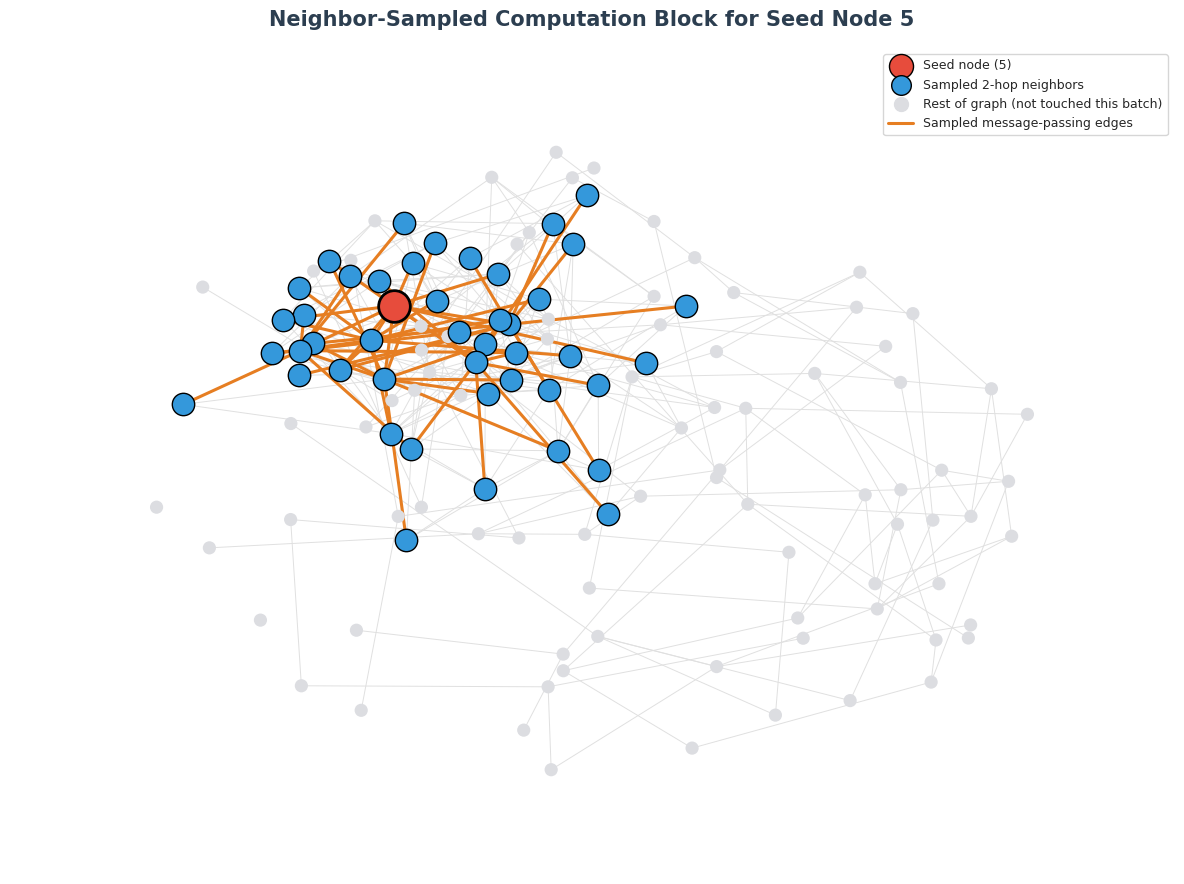

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

seed_node = 5
demo_blocks = build_blocks([seed_node], adj_list, fanouts, rng)
sampled_nodes = set(demo_blocks[0]["input_nodes"])
sampled_edges = set(demo_blocks[0]["edges"]) | set(demo_blocks[1]["edges"])

# Subsample the background graph for a readable figure -- the full 400-node layout is not the point here
bg_nodes = set(rng.choice(list(G.nodes()), size=90, replace=False)) | sampled_nodes | {seed_node}
G_view = G.subgraph(bg_nodes)

fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle(f"Neighbor-Sampled Computation Block for Seed Node {seed_node}", fontsize=15, fontweight="bold", color="#2c3e50")

pos = nx.spring_layout(G_view, seed=3, k=0.5)

nx.draw_networkx_edges(G_view, pos, ax=ax, edge_color="#e0e0e0", width=0.7)
nx.draw_networkx_nodes(G_view, pos, ax=ax, nodelist=list(G_view.nodes()), node_color="#dcdde1",
                        node_size=90, edgecolors="none")

sampled_edge_list = [(u, v) for u, v in [(a, b) for a, b in G_view.edges()]
                      if (u, v) in sampled_edges or (v, u) in sampled_edges]
nx.draw_networkx_edges(G_view, pos, ax=ax, edgelist=sampled_edge_list, edge_color="#e67e22", width=2.2)

layer1_nodes = [v for v in sampled_nodes if v != seed_node]
nx.draw_networkx_nodes(G_view, pos, ax=ax, nodelist=layer1_nodes, node_color="#3498db",
                        node_size=260, edgecolors="black", linewidths=1.0)
nx.draw_networkx_nodes(G_view, pos, ax=ax, nodelist=[seed_node], node_color="#e74c3c",
                        node_size=520, edgecolors="black", linewidths=2.0)

ax.scatter([], [], color="#e74c3c", s=300, edgecolors="black", label=f"Seed node ({seed_node})")
ax.scatter([], [], color="#3498db", s=200, edgecolors="black", label="Sampled 2-hop neighbors")
ax.scatter([], [], color="#dcdde1", s=100, label="Rest of graph (not touched this batch)")
ax.plot([], [], color="#e67e22", linewidth=2.2, label="Sampled message-passing edges")
ax.legend(loc="upper right", fontsize=9, frameon=True)

xs = [x for x, y in pos.values()]
ys = [y for x, y in pos.values()]
ax.set_xlim(min(xs) - 0.3, max(xs) + 0.3)
ax.set_ylim(min(ys) - 0.3, max(ys) + 0.3)
ax.axis("off")
plt.tight_layout()
plt.show()


*(Insight: The red seed node's actual training signal, this batch, comes from only the small cluster of blue nodes reachable via the highlighted orange edges — a tiny, bounded fraction of the hundreds of grey nodes making up the rest of the graph. Every one of those grey nodes is real graph structure the model could in principle learn from, but neighbor sampling deliberately ignores it for THIS gradient step, trading a small amount of estimator variance for a computation graph that stays the same size whether the full graph has 400 nodes or 400 million.)*

## Real-World Use Case or Analogy

Think of DGL's neighbor sampling and distributed training like **A Nationwide Retail Chain's Regional Inventory Sync**:

* **The Full Graph (Every Store's Complete Supply Network):** Ten thousand stores nationwide, each connected to its suppliers, nearby warehouses, and sister stores it swaps inventory with — a network far too large for any single manager to reason about all at once.
* **A Seed Node (One Store Deciding Tonight's Restock Order):** A single store manager needs to decide what to reorder tonight — they don't need to know the FULL national network, just their own recent sales plus a bounded sample of nearby stores' patterns.
* **Fan-Out Sampling (Checking a Fixed Number of Comparable Stores, Not All of Them):** Rather than cross-referencing every one of the chain's 10,000 stores, the manager checks exactly 10 comparable nearby stores, then for each of those, 5 of ITS comparable stores — a fixed, bounded amount of lookup work no matter how big the whole chain gets.
* **A Block (Tonight's Specific Decision-Support Packet):** The bundle of "my sales + my 10 comparable stores' sales + their sub-comparisons" assembled just for tonight's order — thrown away tomorrow and rebuilt fresh with a new sample.
* **Graph Partitioning / METIS (Regional Headquarters Boundaries):** Rather than one national office trying to track every store-to-store relationship, the chain is split into regions drawn to minimize how often supply chains cross regional boundaries — each regional office handles local decisions independently, syncing with neighboring regions only when a relationship genuinely crosses the line.
* **The Edge Cut (Interregional Shipping Costs):** The chain's real, dollar-denominated cost of drawing regional boundaries badly — every supply relationship that crosses a regional line requires more expensive interregional coordination than one handled entirely within a single region's own systems.

No retail chain runs its restocking algorithm by cross-referencing all 10,000 stores for every single order — that would be paralyzing at scale. DGL's neighbor sampling is that same operational discipline applied to graph neural networks: bound the lookup, sample instead of enumerate, and the algorithm stays fast no matter how large the underlying network grows.
